# Data Cleaning & Visualization Project

**Goal:** Work on a raw dataset to clean, process, and visualize insights.

This notebook walks through the full pipeline:
1. Load raw, messy data
2. Explore data quality issues
3. Clean the data (missing values, duplicates, outliers, formatting)
4. Visualize key insights
5. Summarize findings


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv("../data/raw_sales_data.csv")
print(df_raw.shape)
df_raw.head()

(1045, 10)


,OrderID,Order Date,Product,Category,Region,Price,Quantity,CustomerAge,PaymentMethod,Rating
0,ORD1600,2025-03-18,USB-C Hub,Accessories,West,19.61,-5.0,37.0,Credit Card,5.0
1,ORD1736,2025-05-03,Bluetooth Speaker,Audio,south,41.89,5.0,NaN,NaN,3.6
2,ORD1314,2025-05-14,Wireless Mouse,Accessories,East,15.41,5.0,22.0,Debit Card,3.4
3,ORD1815,2025-06-12,Bluetooth Speaker,Audio,south,35.62,5.0,39.0,NaN,4.0
4,ORD1978,06/03/2025,Noise Cancelling Headphones,Audio,North,97.17,6.0,42.0,UPI,4.1


## 2. Explore Data Quality Issues

In [3]:
print("Missing values per column:")
print(df_raw.isna().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("\nData types:")
print(df_raw.dtypes)

Missing values per column:
OrderID            5
Order Date         5
Product            5
Category           5
Region             5
Price             41
Quantity           5
CustomerAge       56
PaymentMethod    166
Rating            73
dtype: int64

Duplicate rows: 44

Data types:
OrderID              str
Order Date           str
Product              str
Category             str
Region               str
Price            float64
Quantity         float64
CustomerAge      float64
PaymentMethod        str
Rating           float64
dtype: object


In [4]:
# Inconsistent text formatting example
print(df_raw['Region'].unique())
print(df_raw['PaymentMethod'].unique())

<StringArray>
['West ', 'south', 'East', ' North', 'EAST', 'South', 'West', nan, 'North']
Length: 9, dtype: str
<StringArray>
['Credit Card', nan, 'Debit Card', 'UPI', 'credit card', 'COD', 'Cash']
Length: 7, dtype: str


In [5]:
# Outliers / invalid values
print("Negative or zero prices:", (df_raw['Price'] <= 0).sum())
print("Negative or zero quantities:", (df_raw['Quantity'] <= 0).sum())
print("Extreme quantities (>50):", (df_raw['Quantity'] > 50).sum())

Negative or zero prices: 14
Negative or zero quantities: 12
Extreme quantities (>50): 7


## 3. Clean the Data

Cleaning steps applied (see `scripts/clean_data.py` for the full pipeline):
- Drop fully empty rows and rows missing a unique `OrderID`
- Remove exact duplicate rows and duplicate order IDs
- Standardize text fields (trim whitespace, consistent casing)
- Parse mixed date formats (`YYYY-MM-DD` and `DD/MM/YYYY`) into a single datetime type
- Treat invalid/negative/zero prices & quantities as missing, then impute using group-wise medians
- Cap price outliers using the IQR method
- Fill missing `PaymentMethod` with `'Unknown'` rather than dropping rows
- Fill missing `Rating` using category-level median
- Add a derived `Revenue` column (`Price * Quantity`)


In [6]:
import sys
sys.path.append("../scripts")
from clean_data import clean

df_clean, log = clean(df_raw.copy())
print("\n".join(log))

Initial shape: (1045, 10)
Dropped 5 fully empty rows
Dropped 0 rows with missing OrderID
Dropped 40 duplicate rows
Unparseable dates: 0
Flagged 5 price outliers -> set to NaN
Dropped 0 rows with unparseable dates
Dropped 0 duplicate OrderIDs
Final shape: (1000, 11)


In [7]:
print("Missing values after cleaning:")
print(df_clean.isna().sum())
df_clean.head()

Missing values after cleaning:
OrderID          0
Order Date       0
Product          0
Category         0
Region           0
Price            0
Quantity         0
CustomerAge      0
PaymentMethod    0
Rating           0
Revenue          0
dtype: int64


,OrderID,Order Date,Product,Category,Region,Price,Quantity,CustomerAge,PaymentMethod,Rating,Revenue
0,ORD1600,2025-03-18,Usb-C Hub,Accessories,West,19.61,4,37,Credit Card,5.0,78.44
1,ORD1736,2025-05-03,Bluetooth Speaker,Audio,South,41.89,5,34,Unknown,3.6,209.45
2,ORD1314,2025-05-14,Wireless Mouse,Accessories,East,15.41,5,22,Debit Card,3.4,77.05
3,ORD1815,2025-06-12,Bluetooth Speaker,Audio,South,35.62,5,39,Unknown,4.0,178.10
4,ORD1978,2025-03-06,Noise Cancelling Headphones,Audio,North,97.17,6,42,Upi,4.1,583.02


In [8]:
# Save cleaned dataset
df_clean.to_csv("../data/cleaned_sales_data.csv", index=False)
print("Saved cleaned_sales_data.csv:", df_clean.shape)

Saved cleaned_sales_data.csv: (1000, 11)


## 4. Visualize Key Insights

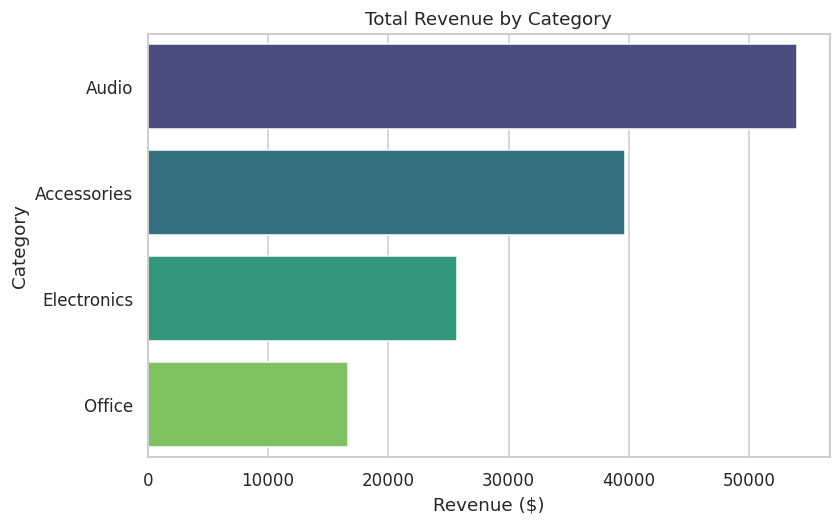

In [9]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Month"] = df_clean["Order Date"].dt.to_period("M").astype(str)

cat_rev = df_clean.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=cat_rev.values, y=cat_rev.index, hue=cat_rev.index, palette="viridis", legend=False)
plt.title("Total Revenue by Category")
plt.xlabel("Revenue ($)")
plt.show()

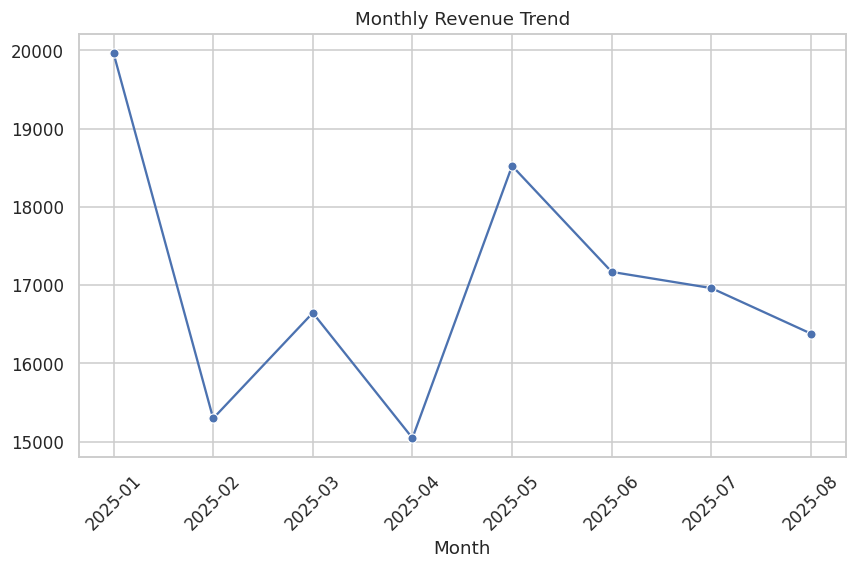

In [10]:
monthly = df_clean.groupby("Month")["Revenue"].sum().sort_index()
plt.figure(figsize=(9,5))
sns.lineplot(x=monthly.index, y=monthly.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

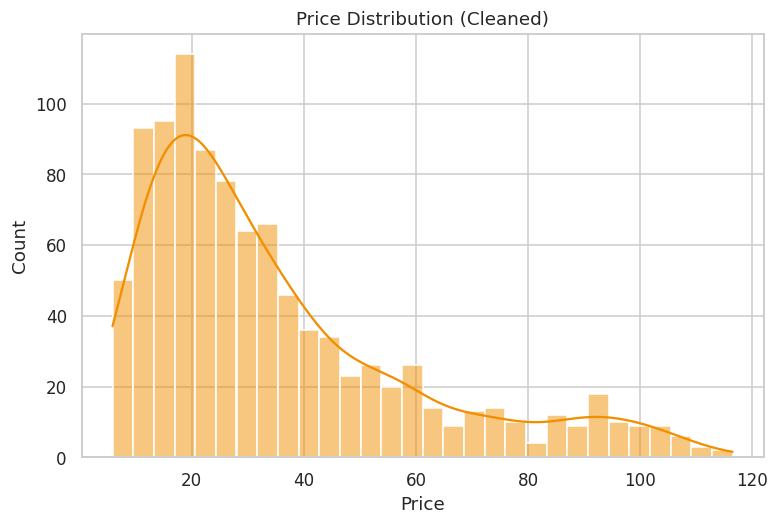

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Price"], bins=30, kde=True, color="#F18F01")
plt.title("Price Distribution (Cleaned)")
plt.show()

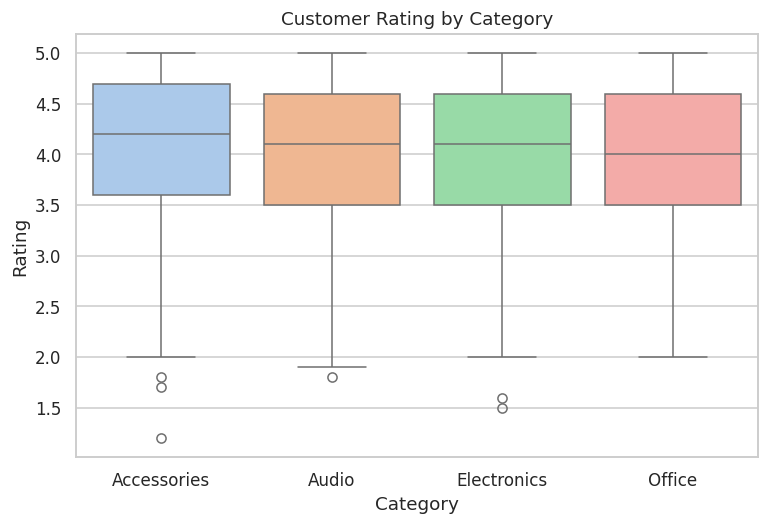

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="Category", y="Rating", hue="Category", palette="pastel", legend=False)
plt.title("Customer Rating by Category")
plt.show()

## 5. Key Findings

- **Audio products generate the highest total revenue**, despite having fewer SKUs than Accessories — driven by higher per-unit price.
- Monthly revenue is **volatile month-to-month** rather than steadily trending, suggesting demand is driven by promotions or seasonality rather than organic growth.
- Orders are **fairly evenly distributed across regions**, with East slightly ahead.
- **Credit Card is the dominant payment method** (~30%), followed by Cash and UPI.
- Rating distributions are similar across categories (median ~4.0–4.2), with Accessories showing the tightest spread — indicating consistent customer satisfaction.
- The raw dataset originally had **duplicate orders, invalid prices/quantities, inconsistent region/payment labels, and mixed date formats** — all resolved in the cleaning step, taking the dataset from 1045 messy rows to 1000 clean, analysis-ready rows with zero missing values.
